In [2]:
from tool3 import *
device = auto_device()
set_seed(0)

In [17]:
X, y = make_triplet_synth(n_classes=4, 
                          per_class=12, 
                          in_dim=8, 
                          seed=2)
X.shape, y[:5]

((48, 8), array([0, 0, 0, 0, 0]))

In [25]:
import torch
enc = TinyEncoder(in_dim=8, out_dim=2)
loss_fn = TripletLoss(margin=0.3)
opt = torch.optim.Adam(enc.parameters(), lr=1e-2)

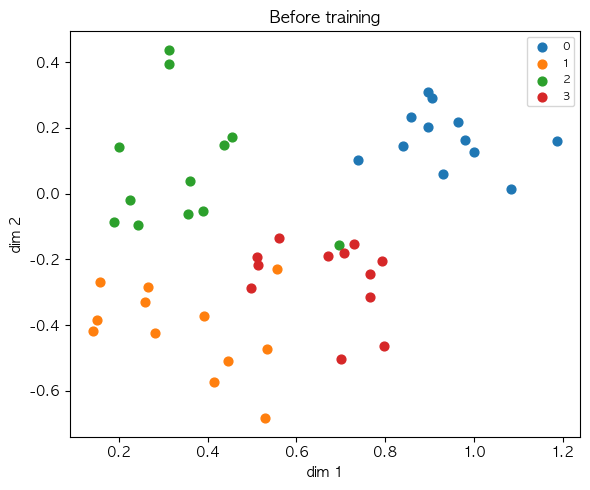

In [26]:
with torch.no_grad():
    Z0 = enc(torch.tensor(X)).numpy()
show_2d_scatter(Z0, labels=y.tolist(), title='Before training')

Text(0.5, 0, 'step')

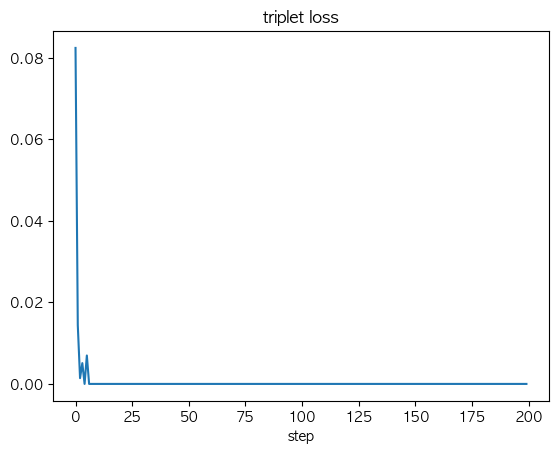

In [27]:
losses = []
for step in range(200):
    a, p, n = make_triplet_batch(X, y, B=32, seed=step)
    a, p, n = map(lambda v: torch.tensor(v), (a, p, n))
    opt.zero_grad()
    L = loss_fn(enc(a), enc(p), enc(n))
    L.backward(); 
    opt.step(); 
    losses.append(float(L))
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('triplet loss');
plt.xlabel('step')

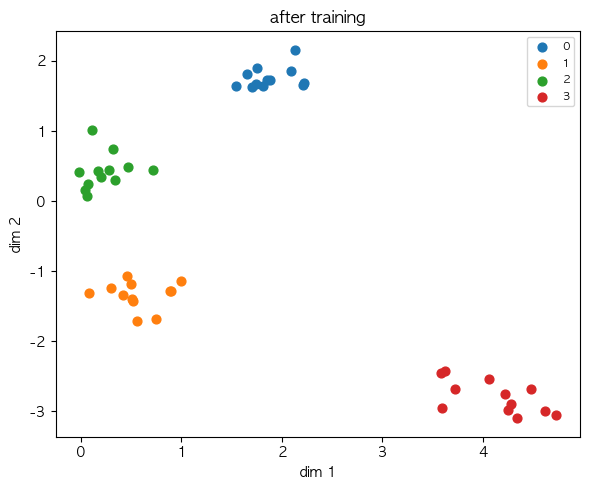

In [28]:
with torch.no_grad():
    Z = enc(torch.tensor(X)).numpy()
show_2d_scatter(Z, labels=y.tolist(), title='after training')